### 1. Introduction
The purpose of this report is to analyze the house rental market in Abu Dhabi, focusing on rental prices, property characteristics, and trends across neighborhoods.

### 2. General Analysis
This section provides an overview of the dataset, including basic statistics about rental properties and their distribution.

### 3. Descriptive Statistics - Rental Prices & Property Characteristics
Statistical measures such as mean, median, and standard deviation for rental prices, sizes.


In [1]:
# Importing Libraries
library(tidyverse)
library(ggplot2)
library(dplyr)
library(summarytools)

# Loading Data
db <- read.csv('rentals_3bedr_Abu_Dhabi_2.csv')

# Data Exploration
head(db)
str(db)
cat("Number of rows: ", nrow(db), "\n")
cat("Maximum Price: ", max(db$Price), "\nMinimum Price: ", min(db$Price), "\n")

# Summary Statistics
summary(db[c('Price', 'Nr.Bedrooms', 'Nr.Bathrooms', 'Size')])

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'summarytools'


The following object is masked from 'package:tibble':

    view




,Price,Nr.Bedrooms,Nr.Bathrooms,Location,Size,X,City
,<int>,<int>,<int>,<chr>,<int>,<chr>,<chr>
1,130000,3,5,"Al Khalidiyah, Abu Dhabi",2500,sqft,Abu Dhabi
2,60000,3,3,"Al Khalidiyah, Abu Dhabi",1800,sqft,Abu Dhabi
3,80400,3,3,"Al Khalidiyah, Abu Dhabi",1900,sqft,Abu Dhabi
4,78000,3,3,"Al Khalidiyah, Abu Dhabi",2000,sqft,Abu Dhabi
5,60000,3,3,"Al Khalidiyah, Abu Dhabi",1600,sqft,Abu Dhabi
6,65000,3,3,"Al Khalidiyah, Abu Dhabi",2000,sqft,Abu Dhabi


'data.frame':	322 obs. of  7 variables:
 $ Price       : int  130000 60000 80400 78000 60000 65000 85000 115000 130000 120000 ...
 $ Nr.Bedrooms : int  3 3 3 3 3 3 3 3 3 3 ...
 $ Nr.Bathrooms: int  5 3 3 3 3 3 4 4 4 4 ...
 $ Location    : chr  " Al Khalidiyah, Abu Dhabi" " Al Khalidiyah, Abu Dhabi" " Al Khalidiyah, Abu Dhabi" " Al Khalidiyah, Abu Dhabi" ...
 $ Size        : int  2500 1800 1900 2000 1600 2000 2000 2852 2368 1960 ...
 $ X           : chr  "sqft" "sqft" "sqft" "sqft" ...
 $ City        : chr  "Abu Dhabi" "Abu Dhabi" "Abu Dhabi" "Abu Dhabi" ...
Number of rows:  322 
Maximum Price:  1400000 
Minimum Price:  50000 


     Price          Nr.Bedrooms  Nr.Bathrooms       Size      
 Min.   :  50000   Min.   :3    Min.   :2.00   Min.   :  451  
 1st Qu.:  80000   1st Qu.:3    1st Qu.:3.00   1st Qu.: 1750  
 Median : 105000   Median :3    Median :4.00   Median : 2000  
 Mean   : 126206   Mean   :3    Mean   :3.85   Mean   : 2296  
 3rd Qu.: 145000   3rd Qu.:3    3rd Qu.:4.00   3rd Qu.: 2400  
 Max.   :1400000   Max.   :3    Max.   :6.00   Max.   :50000  
                                NA's   :1                     

### Plotting
    counts stores the count for each bar

    patches stores the rectangle of each bar

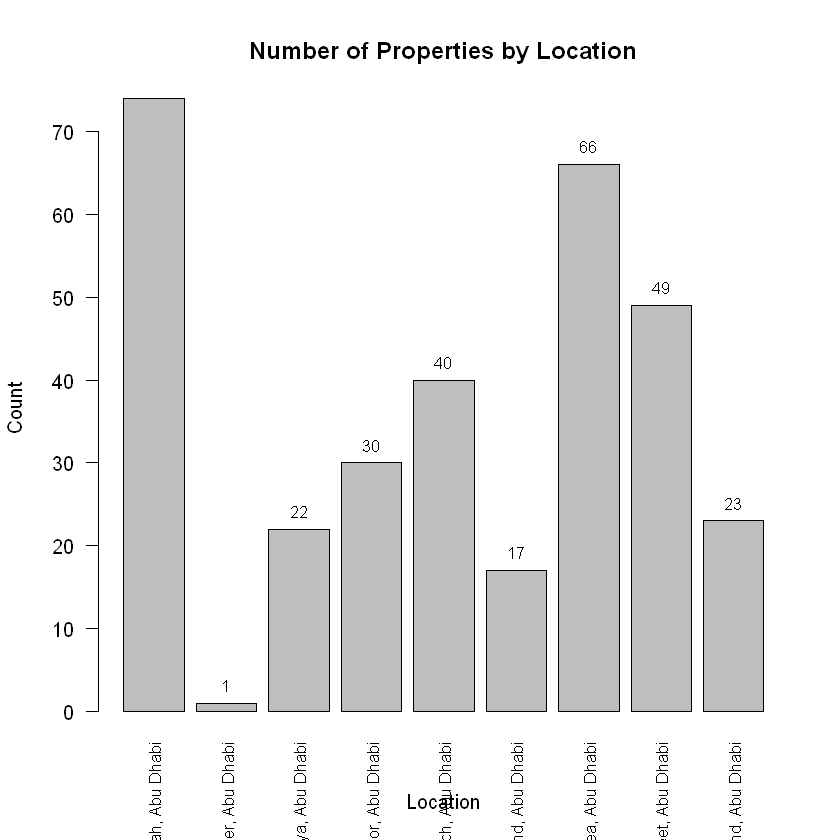

In [2]:
# Create a barplot of property counts by location
counts <- table(db$Location)
barplot_obj <- barplot(counts, 
        main = "Number of Properties by Location",
        xlab = "Location",
        ylab = "Count",
        las = 2,  # Rotates x-axis labels vertically
        cex.names = 0.8)  # Reduces text size for x-axis labels

# Add count labels on top of each bar
text(x = barplot_obj, y = counts + max(counts)*0.03, # Position slightly above bars
     labels = counts, cex = 0.8)

# Adjust margins to ensure labels fit
par(mar = c(10, 4, 4, 2) + 0.1)  # Bottom, left, top, right margins


### 6. Box Plots
#### Rental Prices by Neighborhood
Visual representation of rental price ranges in each neighborhood.

#### Rental Prices by Property Type
Box plots to compare rental prices for different property types.


Location Statistics:
                    Location Price.count Price.mean  Price.std  Price.min
1   Al Khalidiyah, Abu Dhabi       74.00  101248.15   31103.47   55000.00
2     Al Manaseer, Abu Dhabi        1.00   85000.00         NA   85000.00
3    Al Markaziya, Abu Dhabi       22.00  175872.86  276690.55   72500.00
4       Al Muroor, Abu Dhabi       30.00   79666.67   19589.46   50000.00
5   Al Raha Beach, Abu Dhabi       40.00  156891.20   60710.48   80000.00
6  Al Reem Island, Abu Dhabi       17.00  133176.35   42061.39   85000.00
7   Corniche Area, Abu Dhabi       66.00  121166.61   38849.71   60000.00
8   Hamdan Street, Abu Dhabi       49.00   81428.43   19062.45   55000.00
9 Saadiyat Island, Abu Dhabi       23.00  272825.91   68054.53  150000.00
   Price.max
1  180000.00
2   85000.00
3 1400000.00
4  125000.00
5  419999.00
6  270000.00
7  220000.00
8  150000.00
9  430000.00


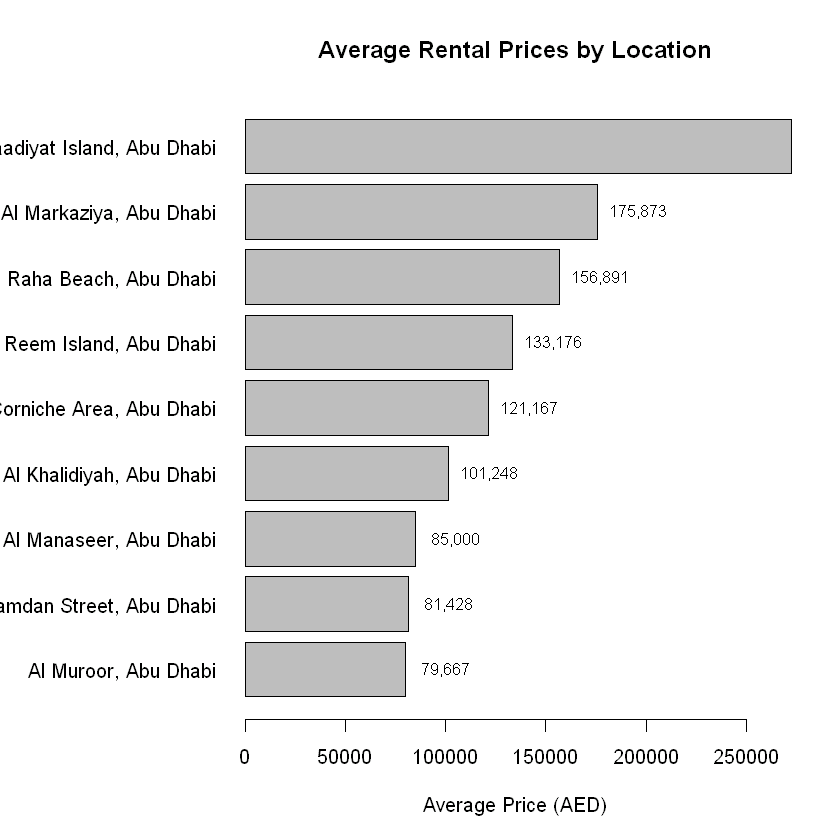

In [3]:
# Create a new plotting window with larger size
par(fig=c(0, 1, 0, 1), mar=c(5, 10, 4, 2))

# Calculate mean prices by location and sort them
location_prices <- aggregate(Price ~ Location, data=db, mean)
location_prices <- location_prices[order(location_prices$Price), ]

# Create horizontal barplot
barplot_obj <- barplot(location_prices$Price, 
                      names.arg=location_prices$Location,
                      main="Average Rental Prices by Location",
                      xlab="Average Price (AED)",
                      ylab="",
                      horiz=TRUE,
                      las=1)  # Makes y-axis labels horizontal

# Add price labels to each bar
text(x=location_prices$Price, y=barplot_obj, 
     labels=format(round(location_prices$Price), big.mark=","), 
     pos=4, cex=0.8)

# Calculate statistics by location
location_stats <- aggregate(Price ~ Location, data=db, 
                           function(x) c(count=length(x), 
                                        mean=mean(x), 
                                        std=sd(x), 
                                        min=min(x), 
                                        max=max(x)))

# Round the statistics to 2 decimal places
location_stats$Price <- round(location_stats$Price, 2)

# Print the statistics table
cat("\nLocation Statistics:\n")
print(location_stats)


The white dots represent individual properties with rental prices that are unusually high or low compared to other properties in the same location.

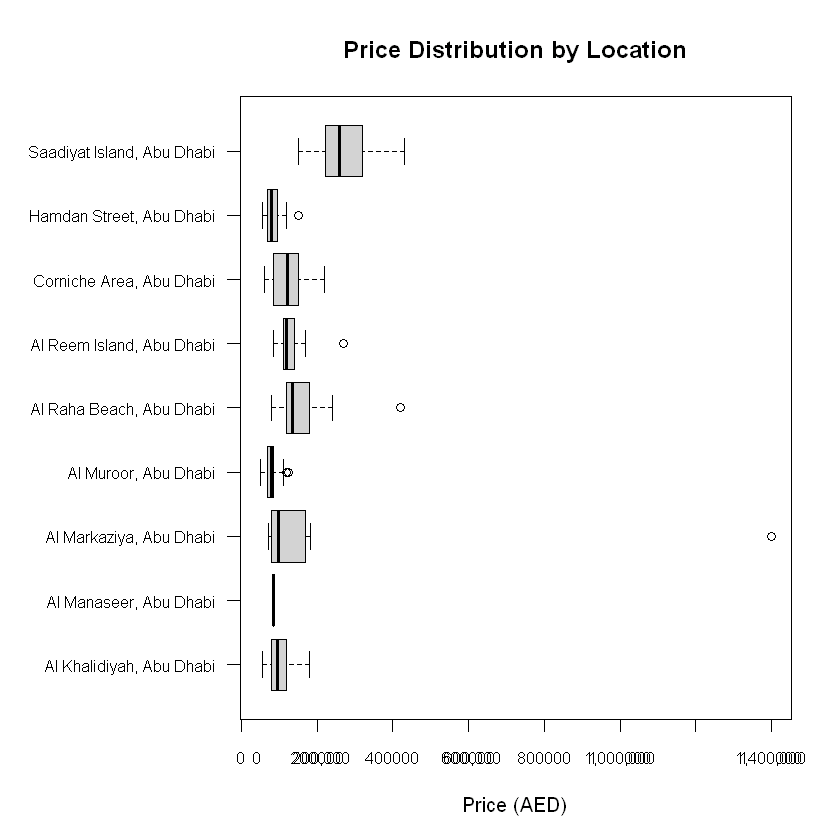

In [4]:
# Create a new plotting window with larger size
par(mar=c(5, 10, 4, 2), cex.axis=0.8)

# Create box plot with horizontal orientation (location on y-axis)
boxplot(Price ~ Location, data=db,
        horizontal=TRUE,
        main="Price Distribution by Location",
        xlab="Price (AED)",
        ylab="",
        las=1)  # Makes y-axis text horizontal

# Format x-axis to show full numbers with commas
axis(1, at=axTicks(1), labels=format(axTicks(1), big.mark=","))

# Adjust layout
par(mar=c(5, 12, 4, 2))  # Increase left margin for location labels


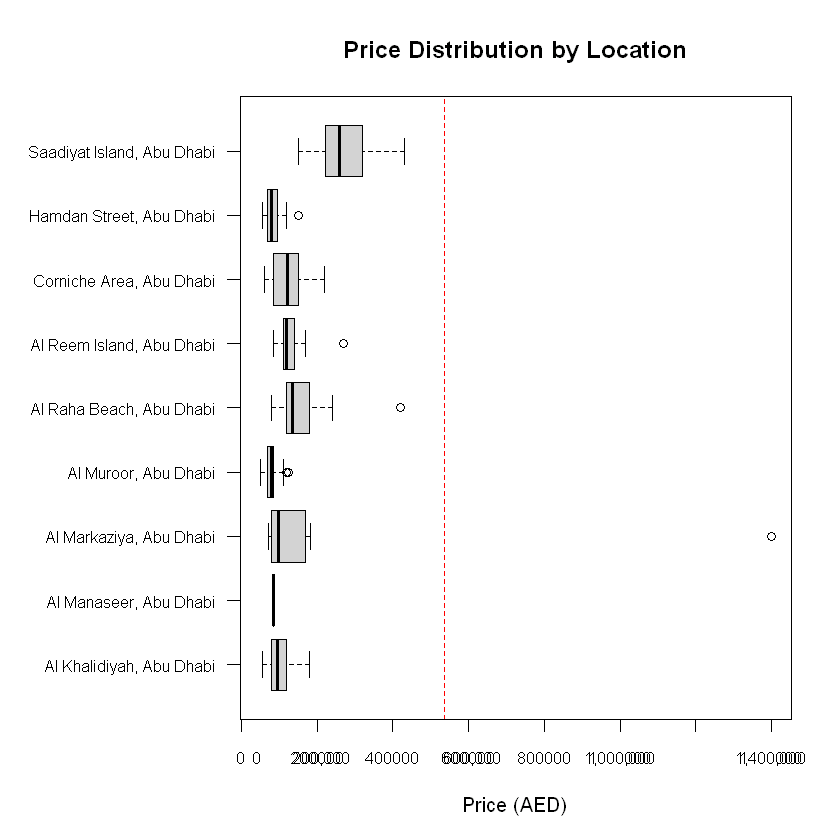

In [5]:
# Calculate price threshold for splitting data (75th percentile + 6 * IQR)
q75 <- quantile(db$Price, 0.75)
q25 <- quantile(db$Price, 0.25)
iqr <- q75 - q25
threshold <- q75 + 6 * iqr

# Set up plotting parameters
par(mar=c(5, 10, 4, 2), cex.axis=0.8)

# Create boxplot with horizontal orientation
boxplot(Price ~ Location, data=db,
        horizontal=TRUE,
        main="Price Distribution by Location",
        xlab="Price (AED)",
        ylab="",
        las=1,
        outline=TRUE)  # Show outliers

# Add vertical line at threshold
abline(v=threshold, col="red", lty=2, lwd=1)

# Add text label for threshold
text(x=threshold, y=par("usr")[4], 
     labels=paste("Threshold:", format(round(threshold), big.mark=",")), 
     pos=4, srt=90, offset=0.5)

# Format x-axis to show full numbers with commas
axis(1, at=axTicks(1), labels=format(axTicks(1), big.mark=","))

# Note: R doesn't have a direct equivalent to 'symlog' scale in base graphics
# The boxplot will show outliers but won't have the same axis break effect
# For a true axis break, consider using the 'plotrix' package if available


### 7. Q-Q Plots
#### Rental Price Distribution
Assessing the normality of rental price distribution using Q-Q plots.

#### Property Size & Rental Prices
Analyzing the relationship between property size and rental prices.


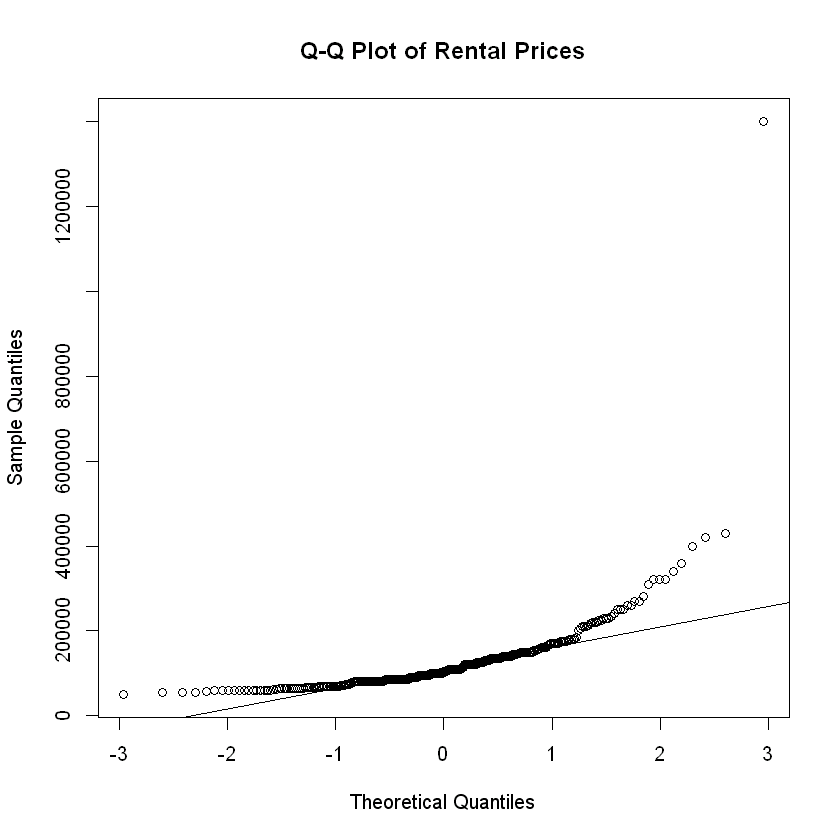

In [6]:
# Create Q-Q plot for rental prices
qqnorm(db$Price, main="Q-Q Plot of Rental Prices")
qqline(db$Price)  # Add reference line

# Add proper axis labels
title(xlab="Theoretical Quantiles", ylab="Sample Quantiles")


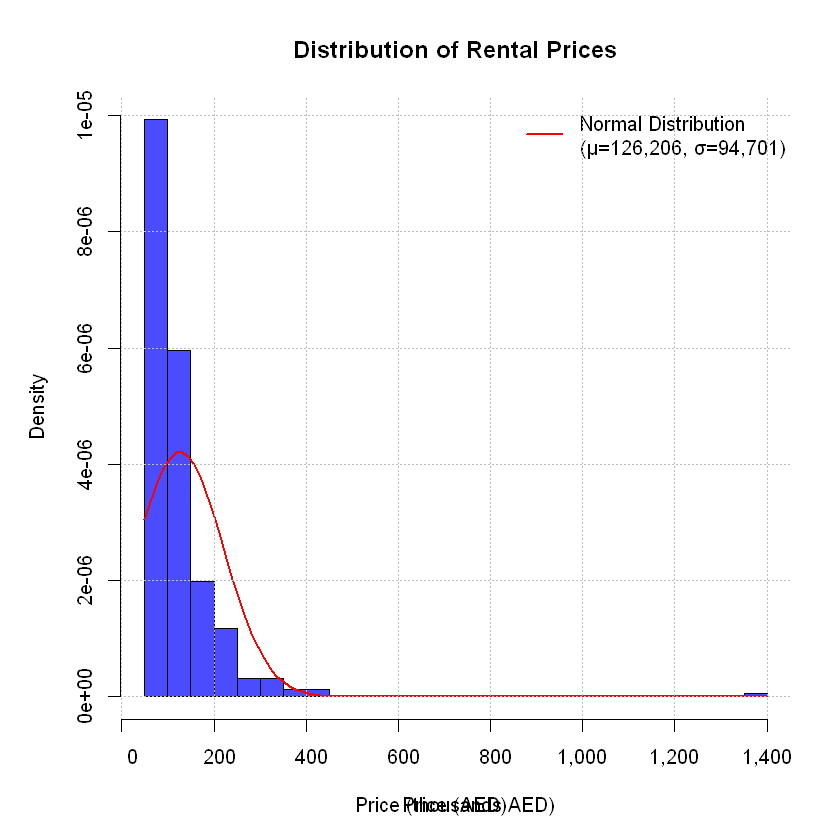

In [9]:
# Set up plotting parameters
par(mar=c(5, 5, 4, 2), cex.main=1.2, cex.lab=1)

# Create histogram with density
hist(db$Price, 
     breaks=30, 
     freq=FALSE,  
     col=rgb(0, 0, 1, 0.7),  
     main="Distribution of Rental Prices",
     xlab="Price (AED)",
     ylab="Density",
     axes=FALSE)  # Suppress default axes so we can create custom ones

# Calculate mean and standard deviation
mu <- mean(db$Price)
sigma <- sd(db$Price)

# Create normal distribution curve
x <- seq(min(db$Price), max(db$Price), length.out=100)
y <- dnorm(x, mean=mu, sd=sigma)

# Add normal distribution curve to the plot
lines(x, y, col="red", lwd=2)

# Add legend
legend_text <- paste0("Normal Distribution\n(μ=", format(round(mu), big.mark=","), 
                     ", σ=", format(round(sigma), big.mark=","), ")")
legend("topright", legend=legend_text, col="red", lwd=2, bty="n")

# Add grid
grid(nx=NULL, ny=NULL, col="gray", lty="dotted")

# Create custom x-axis with better number formatting
axis(1, at=seq(0, max(db$Price), by=200000), 
     labels=format(seq(0, max(db$Price), by=200000)/1000, big.mark=","), 
     las=1)
axis(2)  # Re-add the y-axis

# Add a note for the x-axis values
mtext("Price (thousands AED)", side=1, line=3)

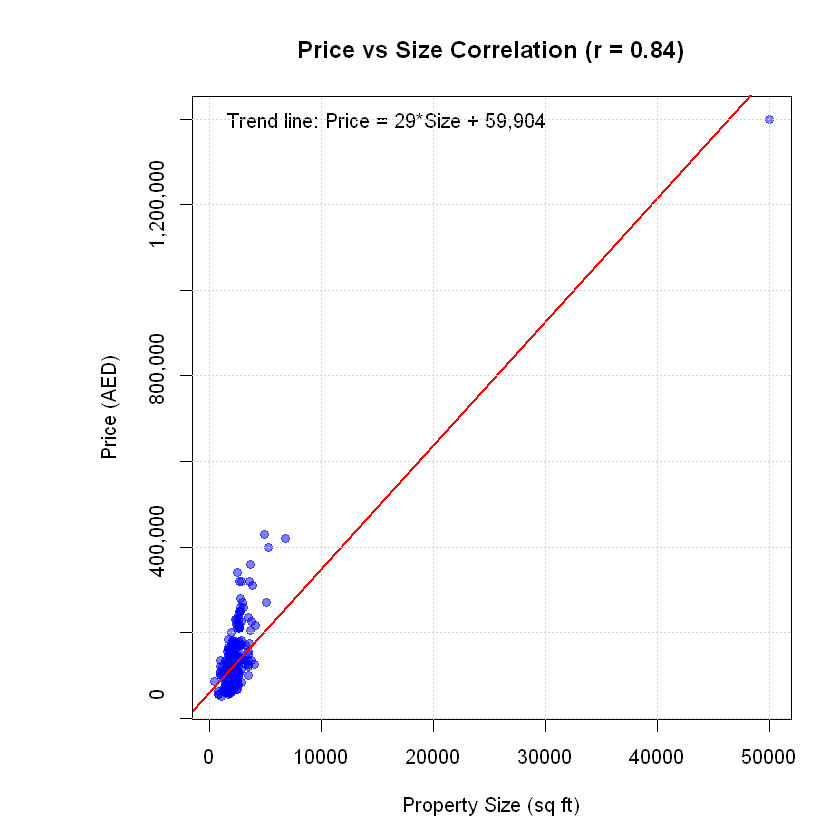

In [12]:
# Calculate correlation
correlation <- cor(db$Size, db$Price)

# Set up plotting parameters
par(mar=c(5, 8, 4, 2))  # Adjust left margin for vertical labels

# Create scatter plot
plot(db$Size, db$Price,
     pch=19,         # Solid circle points
     col=rgb(0,0,1,0.5),  # Blue with 50% transparency
     xlab="Property Size (sq ft)",
     ylab="",        # Empty label as we'll add it later
     main=paste0("Price vs Size Correlation (r = ", round(correlation, 2), ")"),
     yaxt="n")       # Suppress default y-axis

# Add regression line
lm_model <- lm(Price ~ Size, data=db)
abline(lm_model, col="red", lwd=2)

# Format and add vertical y-axis labels
format_with_commas <- function(x) {
  format(x, big.mark=",", scientific=FALSE)
}
axis(2, at=axTicks(2), labels=format_with_commas(axTicks(2)), las=0)  # las=0 makes labels parallel to axis (vertical)

# Add y-axis label with proper positioning
mtext("Price (AED)", side=2, line=3, cex=1)

# Add trend line equation
z <- coef(lm_model)
trend_text <- paste0("Trend line: Price = ", round(z[2]), "*Size + ", 
                    format_with_commas(round(z[1])))

# Add text box for trend line equation
legend("topleft", legend=trend_text, bty="n", 
       box.col="white", bg=rgb(1,1,1,0.8))

# Add grid
grid()

### 9. Confidence Intervals
Calculating confidence intervals for average rental prices across different neighborhoods and property types.


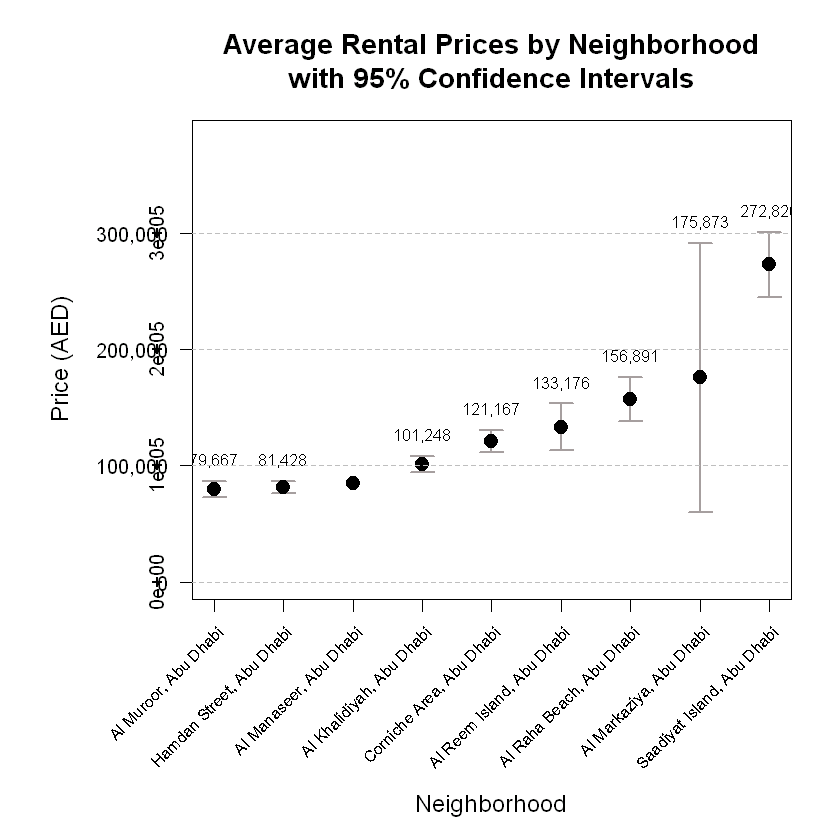

In [13]:
# Calculate statistics by neighborhood
neighborhood_stats <- aggregate(Price ~ Location, data=db, 
                              FUN=function(x) c(mean=mean(x), 
                                               count=length(x), 
                                               std=sd(x)))

# Extract statistics into separate columns
neighborhood_stats$mean <- neighborhood_stats$Price[,"mean"]
neighborhood_stats$count <- neighborhood_stats$Price[,"count"]
neighborhood_stats$std <- neighborhood_stats$Price[,"std"]
neighborhood_stats$Price <- NULL

# Calculate confidence intervals
neighborhood_stats$ci <- 1.96 * neighborhood_stats$std / sqrt(neighborhood_stats$count)

# Sort by mean price
neighborhood_stats <- neighborhood_stats[order(neighborhood_stats$mean), ]

# Set up plotting parameters
par(mar=c(10, 8, 5, 2), cex.main=1.4, cex.lab=1.2)

# Create empty plot with correct dimensions
plot(1:nrow(neighborhood_stats), neighborhood_stats$mean,
     type="n",  # No plotting initially
     ylim=c(0, max(neighborhood_stats$mean) * 1.4),
     xlab="", ylab="",
     xaxt="n",  # Remove x-axis, we'll add custom one
     main="Average Rental Prices by Neighborhood\nwith 95% Confidence Intervals")

# Add error bars
arrows(1:nrow(neighborhood_stats), 
       neighborhood_stats$mean - neighborhood_stats$ci,
       1:nrow(neighborhood_stats), 
       neighborhood_stats$mean + neighborhood_stats$ci,
       angle=90, code=3, length=0.1, col="#a69f9f", lwd=2)

# Add points
points(1:nrow(neighborhood_stats), neighborhood_stats$mean, 
       pch=21, cex=1.5, bg="black")

# Add labels above error bars
for (i in 1:nrow(neighborhood_stats)) {
  y_pos <- neighborhood_stats$mean[i] + neighborhood_stats$ci[i] + 
           (max(neighborhood_stats$mean) * 0.05)
  
  text(i, y_pos, format(round(neighborhood_stats$mean[i]), big.mark=","),
       cex=0.8, adj=c(0.5, 0), 
       bg="white")
}

# Add custom x-axis with rotated labels
axis(1, at=1:nrow(neighborhood_stats), labels=FALSE)
text(1:nrow(neighborhood_stats), 
     par("usr")[3] - (par("usr")[4] - par("usr")[3])*0.05, 
     labels=neighborhood_stats$Location, 
     srt=45, adj=c(1,1), xpd=TRUE, cex=0.8)

# Format y-axis to show full numbers with commas
format_with_commas <- function(x) {
  format(x, big.mark=",", scientific=FALSE)
}
axis(2, at=axTicks(2), labels=format_with_commas(axTicks(2)), las=1)

# Add axis titles
mtext("Neighborhood", side=1, line=8, cex=1.2)
mtext("Price (AED)", side=2, line=5, cex=1.2)

# Add grid lines
grid(nx=NA, ny=NULL, lty="dashed", col="gray", lwd=0.5)

# Everything without outliers
# Box Plot

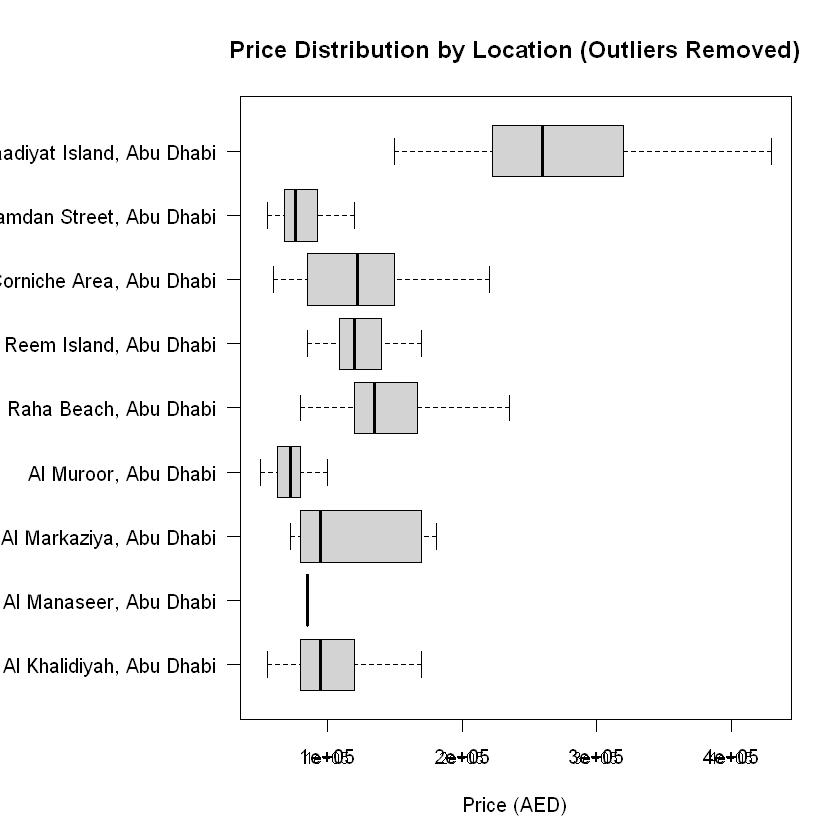

In [14]:
# Create empty dataframe to store filtered data
outlier_filtered_db <- data.frame()

# Calculate outlier cutoffs for Price by Location and filter
for(location in unique(db$Location)) {
  location_data <- subset(db, Location == location)
  
  Q1 <- quantile(location_data$Price, 0.25)
  Q3 <- quantile(location_data$Price, 0.75)
  IQR <- Q3 - Q1
  lower_bound <- Q1 - 1.5 * IQR
  upper_bound <- Q3 + 1.5 * IQR
  
  filtered_location <- subset(location_data, 
                             Price >= lower_bound & Price <= upper_bound)
  
  outlier_filtered_db <- rbind(outlier_filtered_db, filtered_location)
}

# Set up plotting parameters
par(mar=c(5, 10, 4, 2))

# Create boxplot without outliers
boxplot(Price ~ Location, data=outlier_filtered_db,
        horizontal=TRUE,
        main="Price Distribution by Location (Outliers Removed)",
        xlab="Price (AED)",
        ylab="",
        las=1,  # Makes location labels horizontal
        outline=FALSE)  # Don't show outliers (they're already filtered)

# Format x-axis to show full numbers with commas
axis(1, at=axTicks(1), labels=format(axTicks(1), big.mark=","), cex.axis=0.8)


### Q-Q Plots
#### Rental Price Distribution
Assessing the normality of rental price distribution using Q-Q plots.

#### Property Size & Rental Prices
Analyzing the relationship between property size and rental prices.


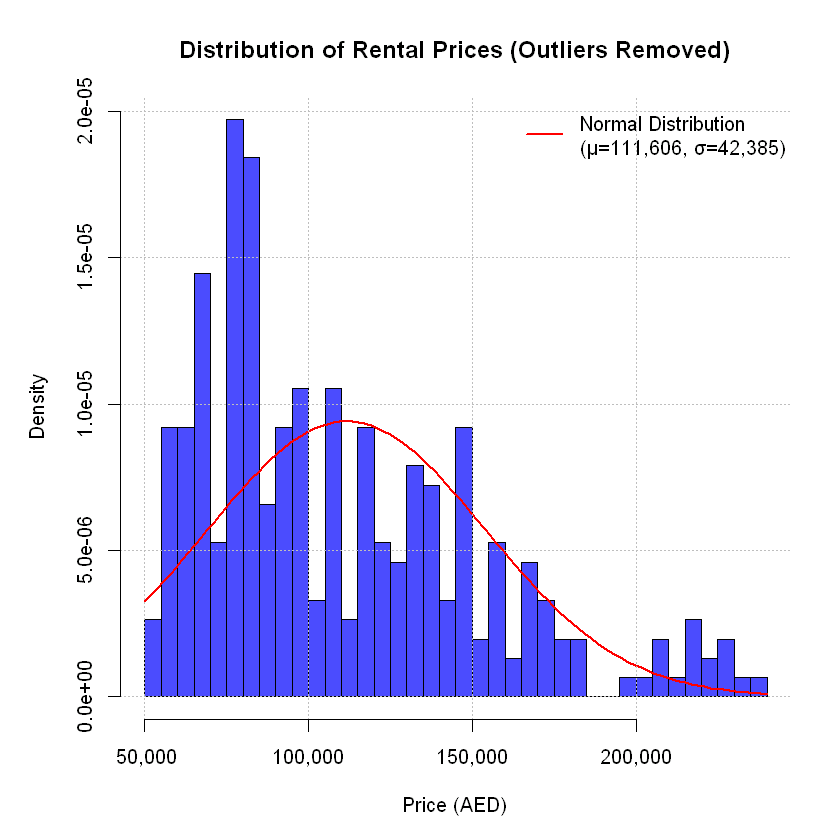

In [15]:
# Remove outliers using IQR method
Q1 <- quantile(db$Price, 0.25)
Q3 <- quantile(db$Price, 0.75)
IQR <- Q3 - Q1
lower_bound <- Q1 - 1.5 * IQR
upper_bound <- Q3 + 1.5 * IQR
filtered_db <- subset(db, Price >= lower_bound & Price <= upper_bound)

# Set up plotting parameters
par(mar=c(5, 5, 4, 2), cex.main=1.2, cex.lab=1)

# Create histogram with density
hist(filtered_db$Price, 
     breaks=30, 
     freq=FALSE,  # Display density instead of counts
     col=rgb(0, 0, 1, 0.7),  # Blue with 0.7 alpha
     main="Distribution of Rental Prices (Outliers Removed)",
     xlab="Price (AED)",
     ylab="Density",
     axes=FALSE)  # Suppress default axes

# Calculate mean and standard deviation
mu <- mean(filtered_db$Price)
sigma <- sd(filtered_db$Price)

# Create normal distribution curve
x <- seq(min(filtered_db$Price), max(filtered_db$Price), length.out=100)
y <- dnorm(x, mean=mu, sd=sigma)

# Add normal distribution curve to the plot
lines(x, y, col="red", lwd=2)

# Add legend
legend_text <- paste0("Normal Distribution\n(μ=", format(round(mu), big.mark=","), 
                     ", σ=", format(round(sigma), big.mark=","), ")")
legend("topright", legend=legend_text, col="red", lwd=2, bty="n")

# Add grid
grid(nx=NULL, ny=NULL, col="gray", lty="dotted")

# Add custom axes with better formatting
axis(1, at=axTicks(1), labels=format(axTicks(1), big.mark=","))
axis(2)  # Standard y-axis

Number of properties removed as outliers: 21

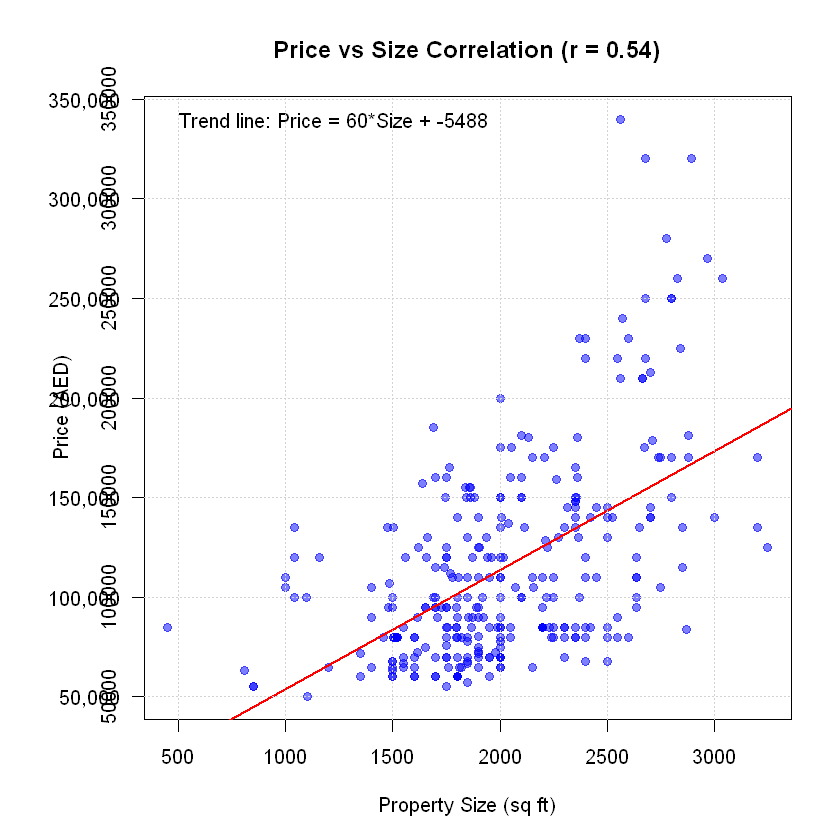

In [16]:
# Remove outliers using IQR method for Size
Q1 <- quantile(db$Size, 0.25)
Q3 <- quantile(db$Size, 0.75)
IQR <- Q3 - Q1
size_outlier_cutoff <- Q3 + 1.5 * IQR
db_filtered <- subset(db, Size <= size_outlier_cutoff)

# Calculate correlation
correlation <- cor(db_filtered$Size, db_filtered$Price)

# Set up plotting parameters
par(mar=c(5, 6, 4, 2))

# Create scatter plot
plot(db_filtered$Size, db_filtered$Price,
     pch=19,         # Solid circle points
     col=rgb(0,0,1,0.5),  # Blue with 50% transparency
     xlab="Property Size (sq ft)",
     ylab="Price (AED)",
     main=paste0("Price vs Size Correlation (r = ", round(correlation, 2), ")"))

# Add regression line
lm_model <- lm(Price ~ Size, data=db_filtered)
abline(lm_model, col="red", lwd=2)

# Format the y-axis with commas
format_with_commas <- function(x) {
  format(x, big.mark=",", scientific=FALSE)
}
axis(2, at=axTicks(2), labels=format_with_commas(axTicks(2)), las=1)

# Add trend line equation
z <- coef(lm_model)
trend_text <- paste0("Trend line: Price = ", round(z[2]), "*Size + ", round(z[1]))

# Add text box for trend line equation
legend("topleft", legend=trend_text, bty="n", 
       box.col="white", bg=rgb(1,1,1,0.8))

# Add grid
grid()

# Print number of outliers removed
cat("Number of properties removed as outliers:", nrow(db) - nrow(db_filtered))

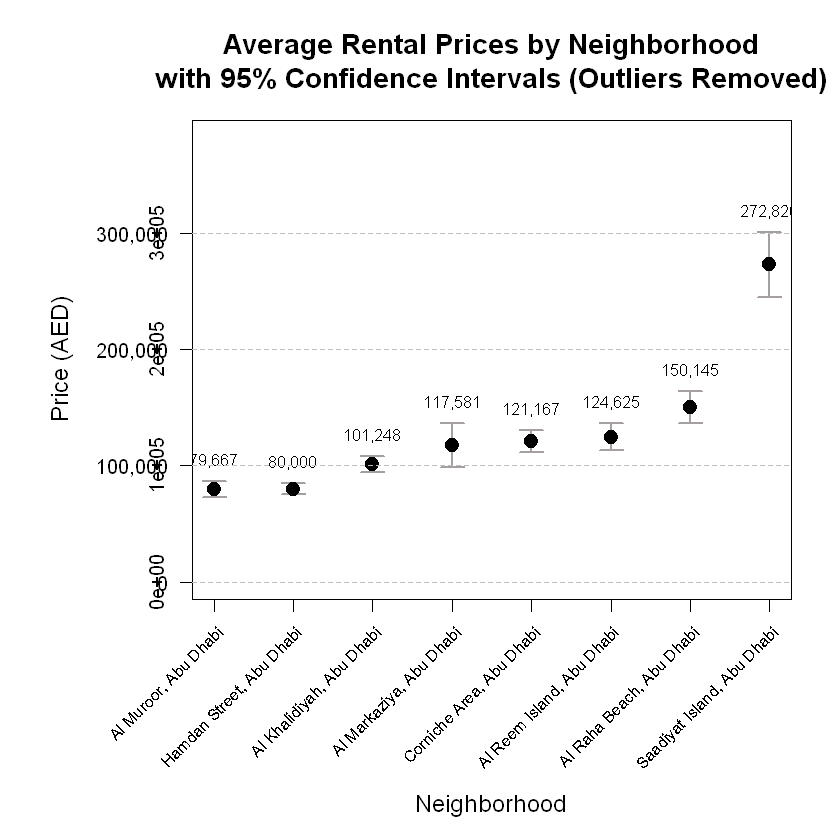

In [18]:
# Calculate outlier thresholds for each neighborhood
outlier_stats <- aggregate(Price ~ Location, data=db, 
                         FUN=function(x) c(mean=mean(x), std=sd(x)))

# Extract statistics into separate columns
outlier_stats$mean <- outlier_stats$Price[,"mean"]
outlier_stats$std <- outlier_stats$Price[,"std"]
outlier_stats$Price <- NULL

# Calculate bounds
outlier_stats$upper_bound <- outlier_stats$mean + 3 * outlier_stats$std
outlier_stats$lower_bound <- outlier_stats$mean - 3 * outlier_stats$std

# Create empty dataframe to store filtered data
filtered_db <- data.frame()

# Filter out outliers based on 3 standard deviations
for(location in unique(db$Location)) {
  location_bounds <- subset(outlier_stats, Location == location)
  location_data <- subset(db, Location == location)
  
  filtered_location <- subset(location_data, 
                             Price <= location_bounds$upper_bound & 
                             Price >= location_bounds$lower_bound)
  
  filtered_db <- rbind(filtered_db, filtered_location)
}

# Calculate statistics on filtered data
neighborhood_stats <- aggregate(Price ~ Location, data=filtered_db, 
                              FUN=function(x) c(mean=mean(x), 
                                               count=length(x), 
                                               std=sd(x)))

# Extract statistics into separate columns
neighborhood_stats$mean <- neighborhood_stats$Price[,"mean"]
neighborhood_stats$count <- neighborhood_stats$Price[,"count"]
neighborhood_stats$std <- neighborhood_stats$Price[,"std"]
neighborhood_stats$Price <- NULL

# Calculate confidence intervals
neighborhood_stats$ci <- 1.96 * neighborhood_stats$std / sqrt(neighborhood_stats$count)

# Sort by mean price
neighborhood_stats <- neighborhood_stats[order(neighborhood_stats$mean), ]

# Set up plotting parameters
par(mar=c(10, 8, 5, 2), cex.main=1.4, cex.lab=1.2)

# Create empty plot with correct dimensions
plot(1:nrow(neighborhood_stats), neighborhood_stats$mean,
     type="n",  # No plotting initially
     ylim=c(0, max(neighborhood_stats$mean) * 1.4),
     xlab="", ylab="",
     xaxt="n",  # Remove x-axis, we'll add custom one
     main="Average Rental Prices by Neighborhood\nwith 95% Confidence Intervals (Outliers Removed)")

# Add error bars
arrows(1:nrow(neighborhood_stats), 
       neighborhood_stats$mean - neighborhood_stats$ci,
       1:nrow(neighborhood_stats), 
       neighborhood_stats$mean + neighborhood_stats$ci,
       angle=90, code=3, length=0.1, col="#a69f9f", lwd=2)

# Add points
points(1:nrow(neighborhood_stats), neighborhood_stats$mean, 
       pch=21, cex=1.5, bg="black")

# Add labels above error bars
for (i in 1:nrow(neighborhood_stats)) {
  y_pos <- neighborhood_stats$mean[i] + neighborhood_stats$ci[i] + 
           (max(neighborhood_stats$mean) * 0.05)
  
  text(i, y_pos, format(round(neighborhood_stats$mean[i]), big.mark=","),
       cex=0.8, adj=c(0.5, 0), 
       bg="white")
}

# Add custom x-axis with rotated labels
axis(1, at=1:nrow(neighborhood_stats), labels=FALSE)
text(1:nrow(neighborhood_stats), 
     par("usr")[3] - (par("usr")[4] - par("usr")[3])*0.05, 
     labels=neighborhood_stats$Location, 
     srt=45, adj=c(1,1), xpd=TRUE, cex=0.8)

# Format y-axis to show full numbers with commas
format_with_commas <- function(x) {
  format(x, big.mark=",", scientific=FALSE)
}
axis(2, at=axTicks(2), labels=format_with_commas(axTicks(2)), las=1)

# Add axis titles
mtext("Neighborhood", side=1, line=8, cex=1.2)
mtext("Price (AED)", side=2, line=5, cex=1.2)

# Add grid lines
grid(nx=NA, ny=NULL, lty="dashed", col="gray", lwd=0.5)